In [ ]:
from functools import partial

import jax
import jax.numpy as jnp
import netket as nk
from flax import nnx
from netket.experimental.operator import FermiHubbardJax

/blue/yujiabin/awwab.azam/NN_Discrete/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Avoid LocalOperator with have N-body operators (N>4). PauliStrings is ok.

**Setup:**
Consider a $L \times L$ square lattice in momentum space. The Hubbard Hamiltonian reads:

$\newcommand{\bsl}[1]{\boldsymbol{#1}}$
\begin{align}
\mathcal{H}_0 &= \sum_{\bsl{k}, \sigma} \varepsilon(\bsl{k}) c*{\bsl{k}\sigma}^{\dagger}c*{\bsl{k}\sigma} \\
\mathcal{H}_{\text{int}} &= \frac{U}{L^2} \sum_{\bsl{k}, \bsl{k'}, \bsl{q}} c*{\bsl{k}+\bsl{q}, \uparrow}^{\dagger} c*{\bsl{k}, \uparrow} c*{\bsl{k'}-\bsl{q}, \downarrow}^{\dagger} c*{\bsl{k'}, \downarrow} \\
\mathcal{H} &= \mathcal{H}_0 + \mathcal{H}_{\text{int}},
\end{align}

where $\varepsilon(\bsl{k}) = -2t\left(\cos (k_x) + \cos(k_y)\right)$, $U$ is the on-site repulsion, and $t$ is the hopping parameter. If we convert this Hamiltonian to real space (which is what our NN expects for input), we get:

$$\mathcal{H}=-t\sum_{\langle{\bsl{i}}, \bsl{j}\rangle{},\sigma} \left(c_{\bsl{i}\sigma}^{\dagger} c_{\bsl{j}\sigma} + c_{\bsl{j}\sigma}^{\dagger} c_{\bsl{i}\sigma}\right) + U\sum_{\bsl{i}}n_{\bsl{i}\uparrow}n_{\bsl{i}\downarrow}$$

**Goal:**
We need to minimize
$$E = \frac{\langle{\Psi}|\mathcal{H}|\Psi\rangle{}}{\langle{\Psi}|\Psi\rangle{}}$$


In [ ]:
# Model parameters
L = 4
n = 10
diff = 0
t = 1.0
U = 2.0

# diff = n_spin_up - n_spin_down
# diff and n should have the same parity
n_spin_up = (n + diff) // 2
n_spin_down = (n - diff) // 2

In [ ]:
# make the lattice
lattice = nk.graph.Square(L, pbc=True)
num_lattice_sites = lattice.n_nodes
print(f"{num_lattice_sites = }")

In [ ]:
# make the Hilbert Space
hi = nk.hilbert.SpinOrbitalFermions(
    num_lattice_sites, s=1 / 2, n_fermions_per_spin=(n_spin_down, n_spin_up)
)

In [ ]:
# 1. Generate a random batch of 5 configurations directly from the Hilbert space
key = jax.random.PRNGKey(42)
mock_x = hi.random_state(key, size=5)

print(f"Shape of mock_x from Hilbert space: {mock_x.shape}")
print(f"What mock_x looks like:\n{mock_x}")

In [ ]:
# define the Hamiltonian
H = FermiHubbardJax(hilbert=hi, t=t, U=U, graph=lattice)
print(f"{H.max_conn_size=}")

In [ ]:
# now implement the NN ansatz

# generic MLP helper class
class MLP(nnx.Module):
    def __init__(
        self,
        hidden_layers: int,
        input_dim: int,
        dim_feedforward: int,
        output_dim: int,
        rngs: nnx.Rngs,
        activation=nnx.gelu,
        # Pass the initializer function here
        kernel_init=nnx.initializers.lecun_normal(),
        bias_init=nnx.initializers.zeros_init(),
    ):
        # Initial layer
        net = [
            nnx.Linear(
                input_dim,
                dim_feedforward,
                rngs=rngs,
                kernel_init=kernel_init,
                bias_init=bias_init,
            ),
            activation,
        ]

        # Hidden layers
        for _ in range(hidden_layers):
            net.append(
                nnx.Linear(
                    dim_feedforward,
                    dim_feedforward,
                    rngs=rngs,
                    kernel_init=kernel_init,
                    bias_init=bias_init,
                )
            )
            net.append(activation)

        # Output layer
        net.append(
            nnx.Linear(
                dim_feedforward,
                output_dim,
                rngs=rngs,
                kernel_init=kernel_init,
                bias_init=bias_init,
            )
        )

        self.MLP = nnx.Sequential(*net)

    def __call__(self, x: jax.Array):
        return self.MLP(x)


# quick helper function
def view_as_complex(x: jax.Array):
    return x[..., 0] + (1j * x[..., 1])


class log_psi_2D_spinful(nnx.Module):
    def __init__(
        self,
        L: int,
        n: int,
        hidden_layers_F: int,
        dim_feedforward_F: int,
        hidden_layers_g: int,
        dim_feedforward_g: int,
        rngs: nnx.Rngs,
        activation=nnx.gelu,
        kernel_init=nnx.initializers.lecun_normal(),
        bias_init=nnx.initializers.zeros_init(),
    ):
        self.L = L
        self.n = n
        # weights, drawn from a Gaussian distribution (for now)
        self.w_s = nnx.Param(rngs.normal((2 * (L**2),)))
        # instantiate MLPs
        self.f = MLP(
            hidden_layers_F,
            5,
            dim_feedforward_F,
            2,
            rngs,
            activation,
            kernel_init,
            bias_init,
        )
        self.g_1_prime = MLP(
            hidden_layers_g,
            1,
            dim_feedforward_g,
            2,
            rngs,
            activation,
            kernel_init,
            bias_init,
        )
        self.g_2_prime = MLP(
            hidden_layers_g,
            1,
            dim_feedforward_g,
            2,
            rngs,
            activation,
            kernel_init,
            bias_init,
        )

    # antisymmetric factor $F: \widetilde{\Lambda}^n \rightarrow \mathbb{C}$
    def F_antisymmetric(self, occ_num: jax.Array):
        # occ_num should be of shape (batch_size, 2*L^2) in an occupation-number basis
        _, nonzero_indices = jax.lax.top_k(occ_num, k=self.n, axis=-1)
        y_indices = nonzero_indices % self.L
        temp = nonzero_indices // self.L
        x_indices = temp % self.L
        spin_indices = temp // self.L
        # now we have x, y, and \sigma
        # convert spatial coords to complex numbers e^{2\pi i x/L}
        z_x = jnp.stack(
            [
                jnp.cos((2 * jnp.pi * x_indices) / self.L),
                jnp.sin((2 * jnp.pi * x_indices) / self.L),
                jnp.cos((2 * jnp.pi * y_indices) / self.L),
                jnp.sin((2 * jnp.pi * y_indices) / self.L),
                (2 * spin_indices) - 1,  # encode spin as ±1
            ],
            axis=-1,
        )  # should be (batch_size, n, 5) now
        # pass through f MLP
        f_x = view_as_complex(self.f(z_x))  # complex (batch_size, n)
        vandermonde_matrix = jax.vmap(partial(jnp.vander, increasing=True))(
            f_x
        )  # should be of shape (batch_size, n, n)
        # take the determinant
        sign, logabsdet = jnp.linalg.slogdet(vandermonde_matrix)
        return (
            sign,  # complex
            logabsdet,  # real
        )  # both should be vectors of shape (batch_size)

    def __call__(self, occ_num: jax.Array):
        # occ_num should be of shape (batch_size, 2*L^2) in an occupation-number basis
        # compute the antisymmetric function F
        sign, logabsdet = self.F_antisymmetric(
            occ_num
        )  # complex/real vectors of shape (batch_size)
        # compute the symmetric function g
        # first calculate eta
        # take matrix-vector product with w_s
        eta = jnp.expand_dims(
            jnp.matmul(occ_num, self.w_s), axis=-1
        )  # shape (batch_size, 1), dtype=float
        # now combine them together via:
        # \Psi = F_1 g_1 + F_2 g_2
        g_1 = view_as_complex(self.g_1_prime(eta))  # shape (batch_size), dtype=complex
        g_2 = view_as_complex(self.g_2_prime(eta))
        # natural log for the final result
        log_psi = logabsdet + jnp.log(
            (sign.real * g_1) + (sign.imag * g_2)
        )  # shape (batch_size), dtype=complex
        return log_psi

In [ ]:
# Instantiate the NN model
model = log_psi_2D_spinful(
    L,
    n,
    hidden_layers_F=3,
    dim_feedforward_F=128,
    hidden_layers_g=3,
    dim_feedforward_g=128,
    rngs=nnx.Rngs(0),
    activation=nnx.gelu,
    kernel_init=nnx.initializers.lecun_normal(),
    bias_init=nnx.initializers.zeros_init(),
)
print(model)

log_psi_2D_spinful( # Param: 150,694 (602.9 KB)
  L=4,
  n=10,
  w_s=Param( # 32 (256 B)
    value=Array(shape=(32,), dtype=dtype('float64'))
  ),
  f=MLP( # Param: 50,562 (202.2 KB)
    MLP=Sequential( # Param: 50,562 (202.2 KB)
      layers=List([
        Linear( # Param: 768 (3.1 KB)
          kernel=Param( # 640 (2.6 KB)
            value=Array(shape=(5, 128), dtype=dtype('float32'))
          ),
          bias=Param( # 128 (512 B)
            value=Array(shape=(128,), dtype=dtype('float32'))
          ),
          in_features=5,
          out_features=128,
          use_bias=True,
          dtype=None,
          param_dtype=float32,
          precision=None,
          dot_general=<function dot_general at 0x1490897cd440>,
          promote_dtype=<function promote_dtype at 0x148ef1a639c0>,
          preferred_element_type=None
        ),
        <function gelu at 0x149088e56f20>,
        Linear( # Param: 16,512 (66.0 KB)
          kernel=Param( # 16,384 (65.5 KB)
            value=A

In [ ]:
# Define a Metropolis exchange sampler
exchange_graph = nk.graph.disjoint_union(lattice, lattice)
print(f"Exchange graph size: {exchange_graph.n_nodes}")
sa = nk.sampler.MetropolisExchange(hi, graph=exchange_graph)
print(sa)

In [ ]:
# Define an optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Create a variational state
vstate = nk.vqs.MCState(sa, model, n_samples=512, n_discard_per_chain=100)

# Create a Variational Monte Carlo with SR driver
gs = nk.driver.VMC_SR(
    H,
    op,
    variational_state=vstate,
    diag_shift=0.1,
    linear_solver=nk.optimizer.solver.pinv_smooth,
    mode="complex",
)

# Construct the logger to visualize the data later on
NN_log = nk.logging.RuntimeLog()

# Run the optimization for _ iterations
gs.run(n_iter=500, out=NN_log)

/blue/yujiabin/awwab.azam/NN_Discrete/.venv/lib/python3.13/site-packages/netket/_src/driver/vmc_sr.py:365: UserWarning: `mode` not selected when working with Fermionic systems. Automatically falling back to `mode='complex'` but for most fermionic calculations where the wave-function is real valued with a sign (not a complex phase) `mode='real'` will truncate the imaginary part of the QGT and lead to the same optimization but at a considerably lower cost (~8 times less).

IT'S LIKELY YOU WANT TO SPECIFY `mode='real'`.


  warn(
  0%|          | 0/500 [00:00<?, ?it/s]E0320 10:32:05.628363  565520 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[160,128]{1,0} fusion(bitcast.96, parameters__params____f____MLP____layers___2___kernel__.1), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":

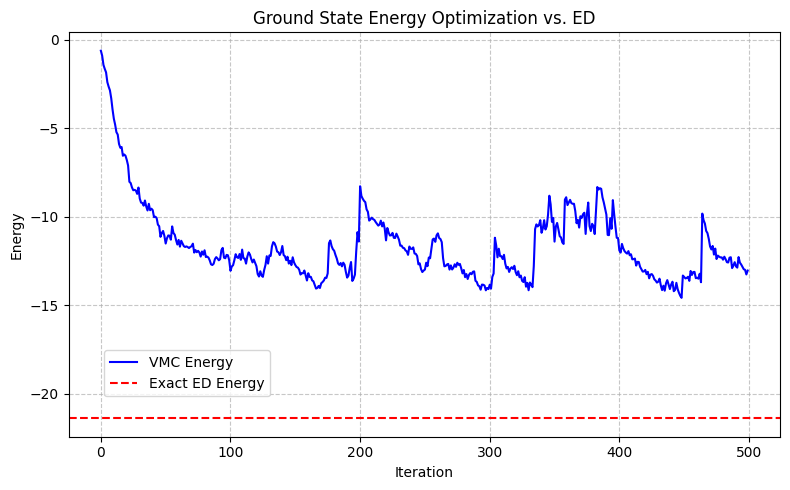

In [ ]:
import matplotlib.pyplot as plt

# Extract iterations and the mean energy values from the log
iters = NN_log["Energy"].iters
energy = NN_log["Energy"]["Mean"].real

# Exact ground state energy from your ED code
E_gs = -21.38

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(iters, energy, color="blue", label="VMC Energy")

# Add the exact ED energy as a horizontal dashed line
plt.axhline(y=E_gs, color="red", linestyle="--", label="Exact ED Energy")

# Formatting the plot
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("Ground State Energy Optimization vs. ED")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(loc=(0.05, 0.1))

# Show the plot
plt.tight_layout()
plt.show()

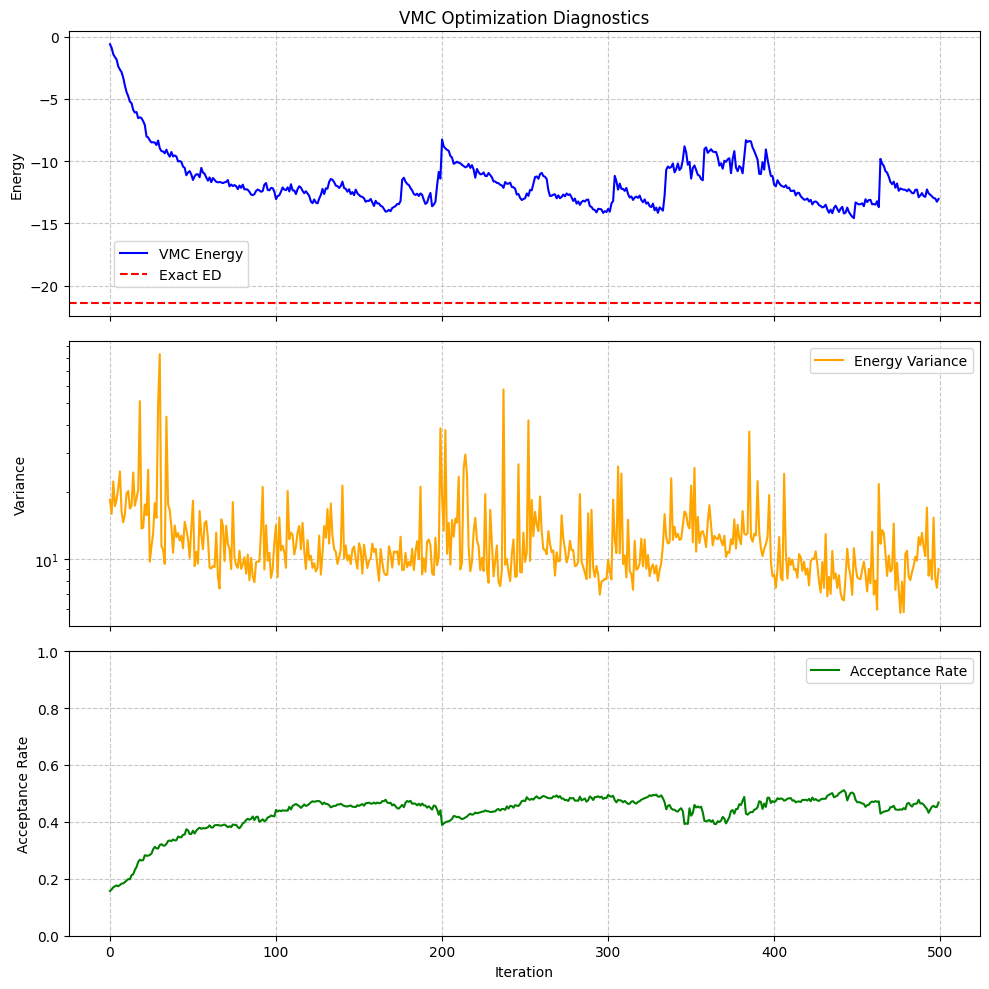

In [ ]:
# Extract data from the log
variance = NN_log["Energy"]["Variance"].real

# Acceptance is just a raw scalar history, not a Stats object
acceptance = NN_log["acceptance"].value

# Create a 3-panel plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 1. Energy Plot
ax1.plot(iters, energy, color="blue", label="VMC Energy")
ax1.axhline(y=E_gs, color="red", linestyle="--", label="Exact ED")
ax1.set_ylabel("Energy")
ax1.set_title("VMC Optimization Diagnostics")
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.legend(loc=(0.05, 0.1))

# 2. Variance Plot
ax2.plot(iters, variance, color="orange", label="Energy Variance")
ax2.set_ylabel("Variance")
ax2.set_yscale("log")
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.legend()

# 3. Acceptance Rate Plot
ax3.plot(iters, acceptance, color="green", label="Acceptance Rate")
ax3.set_ylabel("Acceptance Rate")
ax3.set_xlabel("Iteration")
ax3.set_ylim(0, 1)
ax3.grid(True, linestyle="--", alpha=0.7)
ax3.legend()

plt.tight_layout()
plt.show()

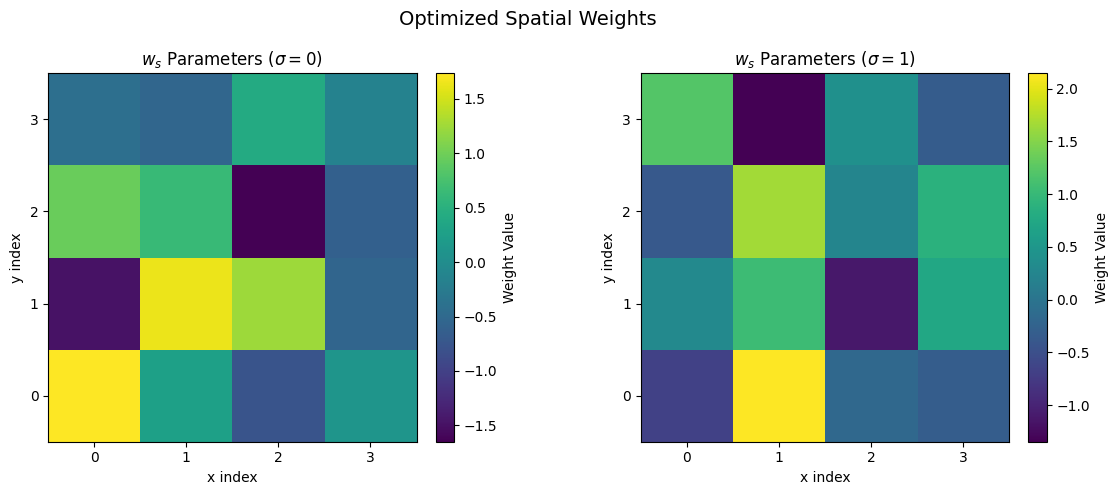

In [ ]:
import numpy as np

# 1. Extract the optimized parameters from the variational state
# NetKet stores the unwrapped JAX arrays in vstate.parameters
try:
    w_s_flat = vstate.parameters["w_s"]
except KeyError:
    # Fallback just in case the parameters are nested under a 'params' key
    w_s_flat = vstate.parameters["params"]["w_s"]

# Convert to a standard NumPy array for plotting
w_s_flat = np.array(w_s_flat)

# 2. Reshape according to your (x, y, sigma) convention
w_s_reshaped = w_s_flat.reshape((L, L, 2))

# Extract the two spin layers
# sigma=0 is typically spin-down and sigma=1 is spin-up (or vice versa depending on your exact mapping)
w_s_spin_0 = w_s_reshaped[:, :, 0]
w_s_spin_1 = w_s_reshaped[:, :, 1]

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Spin 0 Layer ---
# origin='lower' puts the (0,0) coordinate at the bottom-left, standard for lattices
im1 = ax1.imshow(w_s_spin_0, cmap="viridis", origin="lower")
ax1.set_title(r"$w_s$ Parameters ($\sigma = 0$)")
ax1.set_xlabel("x index")
ax1.set_ylabel("y index")
ax1.set_xticks(range(L))
ax1.set_yticks(range(L))
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="Weight Value")

# --- Spin 1 Layer ---
im2 = ax2.imshow(w_s_spin_1, cmap="viridis", origin="lower")
ax2.set_title(r"$w_s$ Parameters ($\sigma = 1$)")
ax2.set_xlabel("x index")
ax2.set_ylabel("y index")
ax2.set_xticks(range(L))
ax2.set_yticks(range(L))
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label="Weight Value")

plt.suptitle("Optimized Spatial Weights", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate global mean and standard deviation
w_s_mean = np.mean(w_s_flat)
w_s_std = np.std(w_s_flat)

print("--- Global w_s Statistics ---")
print(f"Mean: {w_s_mean:.6f}")
print(f"Std Dev: {w_s_std:.6f}\n")

# Calculate per-spin mean and standard deviation
mean_spin_0 = np.mean(w_s_spin_0)
std_spin_0 = np.std(w_s_spin_0)

mean_spin_1 = np.mean(w_s_spin_1)
std_spin_1 = np.std(w_s_spin_1)

print("--- Per-Spin w_s Statistics ---")
print(f"Spin 0 (Down) - Mean: {mean_spin_0:.6f}, Std: {std_spin_0:.6f}")
print(f"Spin 1 (Up)   - Mean: {mean_spin_1:.6f}, Std: {std_spin_1:.6f}")

--- Global w_s Statistics ---
Mean: 0.161963
Std Dev: 0.967541

--- Per-Spin w_s Statistics ---
Spin 0 (Down) - Mean: 0.053544, Std: 0.960157
Spin 1 (Up)   - Mean: 0.270381, Std: 0.962736


/scratch/local/27548528/ipykernel_564986/1444709891.py:7: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  w_s_flat = model.w_s.value


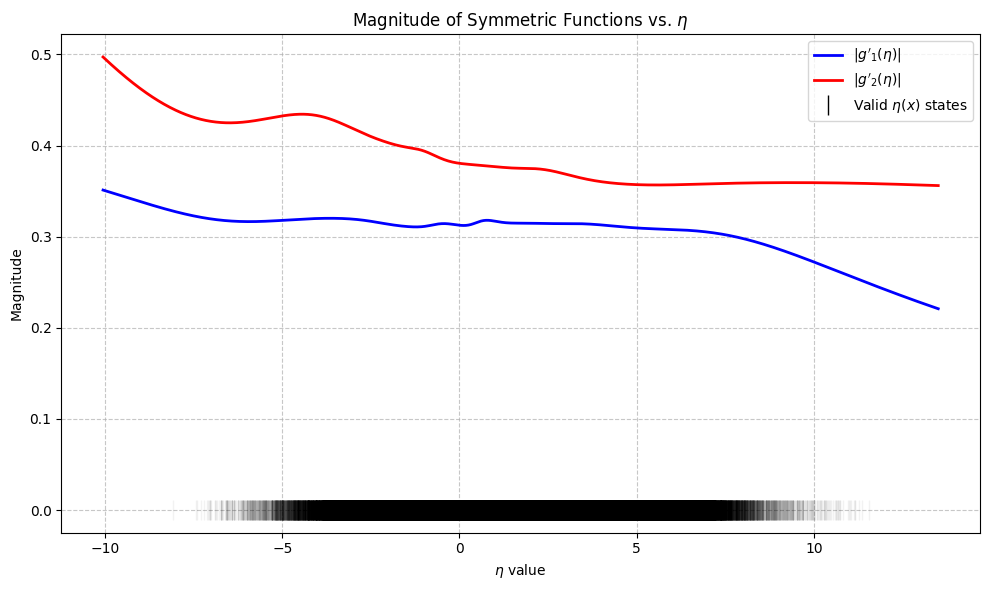

In [ ]:
# 1. Re-inject the optimized parameters into your NNX model
# Use vstate.parameters to skip the top-level 'params' wrapper
nnx.update(model, vstate.parameters)

# Extract the flat w_s array directly from the module now that it's updated
# (or you can just pull it from vstate.parameters['w_s'] directly)
w_s_flat = model.w_s.value


# 2. Define the transformation to calculate eta from occupation numbers
@jax.jit
def calculate_eta_batch(occ_num, w_s):
    # Extract indices of the n particles (replicating your __call__ logic)
    _, nonzero_indices = jax.lax.top_k(occ_num, k=n, axis=-1)
    y_indices = nonzero_indices % L
    temp = nonzero_indices // L
    x_indices = temp % L
    spin_indices = temp // L

    # Apply your specific flat indexing convention
    x_mapped = ((2 * L) * (x_indices % L)) + (2 * (y_indices % L)) + spin_indices

    # Calculate N_s and take the dot product with the spatial weights
    N_s = jax.nn.one_hot(x_mapped, num_classes=2 * (L**2)).sum(axis=1)
    return jnp.matmul(N_s, w_s)


# 3. Uniformly sample the Hilbert space to find the distribution of eta
key = jax.random.PRNGKey(123)
sample_states = hi.random_state(key, size=100000)
etas_sampled = calculate_eta_batch(sample_states, w_s_flat)

# Find the bounds of eta to define our continuous interval
min_eta = float(jnp.min(etas_sampled))
max_eta = float(jnp.max(etas_sampled))

# Add a 10% buffer on the edges for the plot interval
padding = (max_eta - min_eta) * 0.1
eta_continuous = jnp.linspace(min_eta - padding, max_eta + padding, 1000)

# 4. Evaluate the MLPs over the continuous interval
eta_expanded = jnp.expand_dims(eta_continuous, axis=-1)

# Forward pass through g_1' and g_2' using the updated model state
g1_out = model.g_1_prime(eta_expanded)
g2_out = model.g_2_prime(eta_expanded)


# Helper to calculate magnitude
def get_magnitude(x):
    return jnp.abs(x[..., 0] + (1j * x[..., 1]))


mag_g1 = get_magnitude(g1_out)
mag_g2 = get_magnitude(g2_out)

# 5. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot continuous MLP magnitudes
ax.plot(eta_continuous, mag_g1, color="blue", linewidth=2, label=r"$|g'_1(\eta)|$")
ax.plot(eta_continuous, mag_g2, color="red", linewidth=2, label=r"$|g'_2(\eta)|$")

# Plot the sampled eta values as a "rug plot" on the x-axis to show where the physics actually happens
ax.plot(
    etas_sampled,
    np.zeros_like(etas_sampled),
    "|",
    color="black",
    alpha=0.05,
    markersize=15,
    label=r"Valid $\eta(x)$ states",
)

ax.set_xlabel(r"$\eta$ value")
ax.set_ylabel("Magnitude")
ax.set_title(r"Magnitude of Symmetric Functions vs. $\eta$")
ax.grid(True, linestyle="--", alpha=0.7)

# Fix alpha for the legend so the rug plot icon is visible
leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

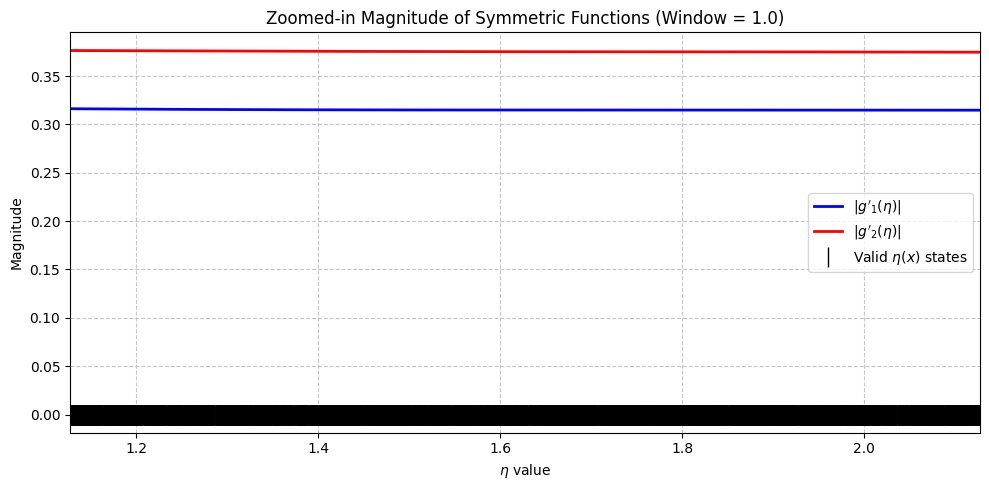

In [ ]:
# 1. Choose a narrow window around the center of your data
center_eta = float(jnp.mean(etas_sampled))
window_size = 1.0  # You can shrink this to 0.1 or 0.01 for an even tighter zoom

# 2. Create a highly dense array of eta values just for this small slice
eta_zoomed = jnp.linspace(
    center_eta - (window_size / 2), center_eta + (window_size / 2), 2000
)
eta_zoomed_expanded = jnp.expand_dims(eta_zoomed, axis=-1)

# 3. Evaluate the MLPs at this high resolution
g1_out_zoomed = model.g_1_prime(eta_zoomed_expanded)
g2_out_zoomed = model.g_2_prime(eta_zoomed_expanded)

mag_g1_zoomed = get_magnitude(g1_out_zoomed)
mag_g2_zoomed = get_magnitude(g2_out_zoomed)

# Filter the rug plot states to only plot the ones inside our zoomed window
etas_in_window = etas_sampled[
    (etas_sampled >= center_eta - (window_size / 2))
    & (etas_sampled <= center_eta + (window_size / 2))
]

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(eta_zoomed, mag_g1_zoomed, color="blue", linewidth=2, label=r"$|g'_1(\eta)|$")
ax.plot(eta_zoomed, mag_g2_zoomed, color="red", linewidth=2, label=r"$|g'_2(\eta)|$")

# Rug plot for the states in this specific slice
ax.plot(
    etas_in_window,
    np.zeros_like(etas_in_window),
    "|",
    color="black",
    alpha=0.3,
    markersize=15,
    label=r"Valid $\eta(x)$ states",
)

ax.set_xlim(center_eta - (window_size / 2), center_eta + (window_size / 2))
ax.set_xlabel(r"$\eta$ value")
ax.set_ylabel("Magnitude")
ax.set_title(f"Zoomed-in Magnitude of Symmetric Functions (Window = {window_size})")
ax.grid(True, linestyle="--", alpha=0.7)

# Fix alpha for the legend
leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

In [ ]:
# E_gs = -9.460138475599
# sd_energy = vstate.expect(H)
# error = abs((sd_energy.mean - E_gs) / E_gs)

# print(f"Optimized energy : {sd_energy}")
# print(f"Relative error   : {error}")

In [ ]:
def count_params(model):
    params = nnx.state(model, nnx.Param)
    leaves = jax.tree_util.tree_leaves(params)
    return sum(x.size for x in leaves)


count_params(model)